In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, pandas as pd

DRIVE_ROOT = "/content/drive/MyDrive/NIH"
DRIVE_IMG_DIR = os.path.join(DRIVE_ROOT, "images")

TRAIN_CSV = "/content/nih-cxr-lt_single-label_train.csv"
VAL_CSV   = "/content/nih-cxr-lt_single-label_balanced-val.csv"
TEST_CSV  = "/content/nih-cxr-lt_single-label_test.csv"

Mounted at /content/drive


In [3]:
!python batch_download_zips.py

downloadingimages_01.tar.gz...
downloadingimages_02.tar.gz...
downloadingimages_03.tar.gz...
downloadingimages_04.tar.gz...
downloadingimages_05.tar.gz...
downloadingimages_06.tar.gz...
downloadingimages_07.tar.gz...
downloadingimages_08.tar.gz...
downloadingimages_09.tar.gz...
downloadingimages_10.tar.gz...
downloadingimages_11.tar.gz...
downloadingimages_12.tar.gz...
Download complete. Please check the checksums


In [4]:
from pathlib import Path

RUNTIME_EXTRACT = "/content/NIH_local_images"

Path(RUNTIME_EXTRACT).mkdir(parents=True, exist_ok=True)

print("Folder is ready.")

Folder is ready.


In [5]:
import glob
import subprocess

tar_files = sorted(glob.glob("/content/images_*.tar.gz"))

print("Found files:", tar_files)

for tar_file in tar_files:
    print(f"\nExtracting {tar_file} ...")
    subprocess.run(
        ["tar", "-xzf", tar_file, "-C", RUNTIME_EXTRACT],
        check=True
    )
    os.remove(tar_file)
    print(f"Deleted {tar_file} to free space.")

print("\nAll archives extracted.")

Found files: ['/content/images_01.tar.gz', '/content/images_02.tar.gz', '/content/images_03.tar.gz', '/content/images_04.tar.gz', '/content/images_05.tar.gz', '/content/images_06.tar.gz', '/content/images_07.tar.gz', '/content/images_08.tar.gz', '/content/images_09.tar.gz', '/content/images_10.tar.gz', '/content/images_11.tar.gz', '/content/images_12.tar.gz']

Extracting /content/images_01.tar.gz ...
Deleted /content/images_01.tar.gz to free space.

Extracting /content/images_02.tar.gz ...
Deleted /content/images_02.tar.gz to free space.

Extracting /content/images_03.tar.gz ...
Deleted /content/images_03.tar.gz to free space.

Extracting /content/images_04.tar.gz ...
Deleted /content/images_04.tar.gz to free space.

Extracting /content/images_05.tar.gz ...
Deleted /content/images_05.tar.gz to free space.

Extracting /content/images_06.tar.gz ...
Deleted /content/images_06.tar.gz to free space.

Extracting /content/images_07.tar.gz ...
Deleted /content/images_07.tar.gz to free space.



In [6]:
!find /content/NIH_local_images/images -type f -name "*.png" | wc -l

112120


In [7]:
IMG_DIR = "/content/NIH_local_images/images"

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

print("train/val:", len(train_df), len(val_df))
print(train_df.columns)

train/val: 68058 300
Index(['id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
       'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax',
       'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema',
       'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding',
       'subject_id'],
      dtype='object')


In [9]:
IMG_COL = "id"
IGNORE_COLS = {"id", "subject_id"}
LABEL_COLS = [c for c in train_df.columns if c not in IGNORE_COLS]

print("Num labels:", len(LABEL_COLS))
print(LABEL_COLS)

Num labels: 20
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']


In [10]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import os

train_tfms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(7),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_tfms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class CXRMultiLabelDataset(Dataset):
    def __init__(self, df, img_dir, img_col, label_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.img_col = img_col
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row[self.img_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        y = torch.tensor(row[self.label_cols].values.astype("float32"))
        return img, y

BATCH_SIZE = 128
NUM_WORKERS = 8

train_ds = CXRMultiLabelDataset(train_df, IMG_DIR, IMG_COL, LABEL_COLS, train_tfms)
val_ds   = CXRMultiLabelDataset(val_df,   IMG_DIR, IMG_COL, LABEL_COLS, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([128, 3, 224, 224]) torch.Size([128, 20])


In [11]:
import torch, torch.nn as nn, torchvision.models as models
import numpy as np
import torch.optim as optim

torch.backends.cudnn.benchmark = True
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================
# ResNet50 (pretrained ImageNet)
# =====================
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(LABEL_COLS))
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"ResNet50 total parameters: {total_params:,}")

# Loss, optimizer, scheduler — same as DenseNet pipeline
pos = train_df[LABEL_COLS].sum(axis=0).values
neg = len(train_df) - pos
pos_weight = torch.tensor(neg / (pos + 1e-6), dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

scaler = torch.amp.GradScaler("cuda")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 126MB/s]


ResNet50 total parameters: 23,549,012


In [12]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    probs_all, targets_all = [], []

    for x, y in tqdm(loader, desc="val"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        targets_all.append(y.cpu().numpy())

    probs_all = np.concatenate(probs_all, 0)
    targets_all = np.concatenate(targets_all, 0)
    avg_loss = total_loss / len(loader.dataset)

    aucs = []
    for i in range(targets_all.shape[1]):
        if len(np.unique(targets_all[:, i])) < 2:
            continue
        aucs.append(roc_auc_score(targets_all[:, i], probs_all[:, i]))
    mean_auc = float(np.mean(aucs)) if aucs else float("nan")
    return avg_loss, mean_auc

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for x, y in tqdm(loader, desc="train"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

EPOCHS = 30
patience = 8
bad_epochs = 0
best_auc = -1

SAVE_PATH = "/content/drive/MyDrive/NIH/models/resnet50_multilabel_best.pt"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    va_loss, va_auc = evaluate(model, val_loader)
    scheduler.step()

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"  train loss: {tr_loss:.4f}")
    print(f"  val   loss: {va_loss:.4f} | mean AUC: {va_auc:.4f}")

    if va_auc > best_auc:
        best_auc = va_auc
        bad_epochs = 0
        torch.save({"model_state": model.state_dict(), "label_cols": LABEL_COLS}, SAVE_PATH)
        print(f"Saved best (AUC={best_auc:.4f}) \u2192 {SAVE_PATH}")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping (no AUC improvement)")
            break

val: 100%|██████████| 3/3 [00:03<00:00,  1.12s/it]



Epoch 1/30
  train loss: 1.3726
  val   loss: 96.6029 | mean AUC: 0.6084
Saved best (AUC=0.6084) → /content/drive/MyDrive/NIH/models/resnet50_multilabel_best.pt


val: 100%|██████████| 3/3 [00:02<00:00,  1.05it/s]



Epoch 2/30
  train loss: 1.3161
  val   loss: 77.1335 | mean AUC: 0.6030


val: 100%|██████████| 3/3 [00:02<00:00,  1.05it/s]


...


Epoch 14/30
  train loss: 1.1359
  val   loss: 81.4041 | mean AUC: 0.6375


val: 100%|██████████| 3/3 [00:02<00:00,  1.05it/s]



Epoch 15/30
  train loss: 1.1168
  val   loss: 82.1325 | mean AUC: 0.6458


val: 100%|██████████| 3/3 [00:02<00:00,  1.05it/s]


Epoch 16/30
  train loss: 1.1008
  val   loss: 101.9704 | mean AUC: 0.6452
Early stopping (no AUC improvement)


✅ Paths ok.
Test rows: 20279
Num labels: 20
✅ Loaded checkpoint into fresh ResNet50 model: /content/drive/MyDrive/NIH/models/resnet50_multilabel_best.pt

✅ TEST mean AUC (over 20 valid classes): 0.6318
Saved metrics: /content/drive/MyDrive/NIH/reports_resnet/test_metrics.json

Top AUCs:
  Edema                          0.825
  Consolidation                  0.756
  Hernia                         0.718
  Effusion                       0.693
  Tortuous Aorta                 0.687
  Subcutaneous Emphysema         0.660
  Calcification of the Aorta     0.658
  Pneumonia                      0.649
  Fibrosis                       0.647
  Cardiomegaly                   0.644

Bottom AUCs:
  Atelectasis                    0.637
  No Finding                     0.619
  Emphysema                      0.617
  Infiltration                   0.615
  Pneumothorax                   0.602
  Nodule                         0.569
  Pneumoperitoneum               0.569
  Mass                           0.

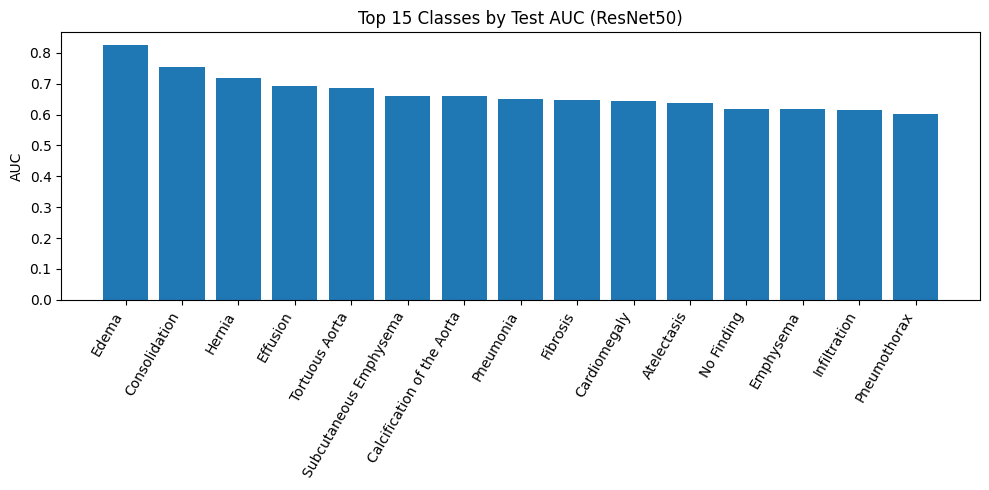

Saved: /content/drive/MyDrive/NIH/reports_resnet/auc_top15.png


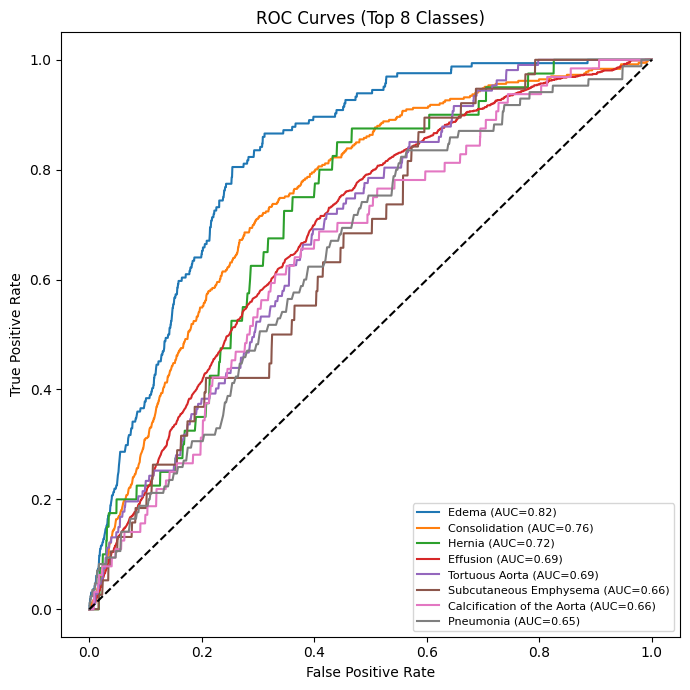

Saved: /content/drive/MyDrive/NIH/reports_resnet/roc_topN.png


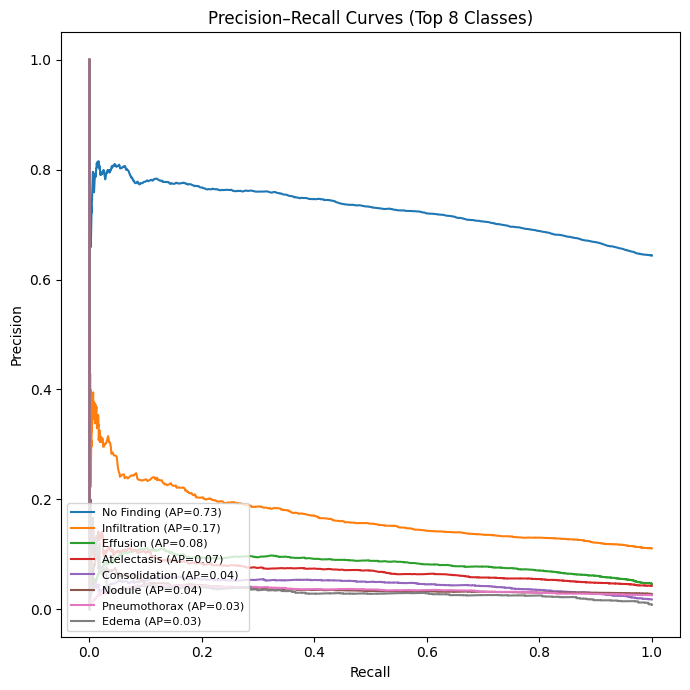

Saved: /content/drive/MyDrive/NIH/reports_resnet/pr_topN.png


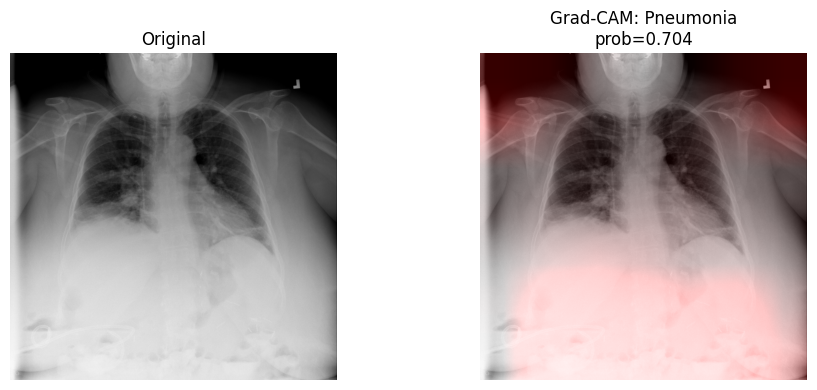

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Pneumonia_0.png


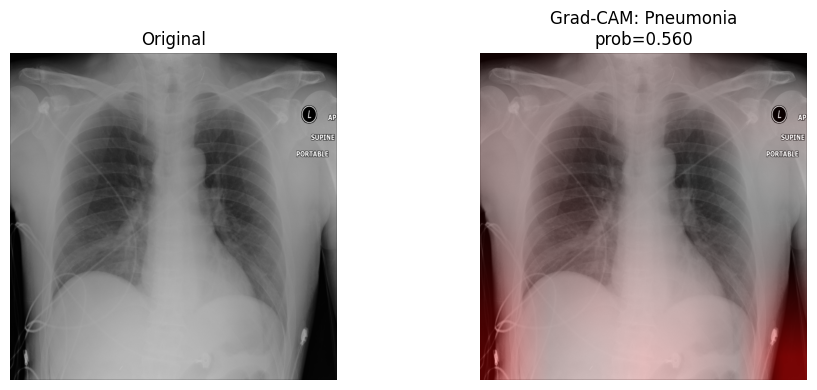

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Pneumonia_1.png


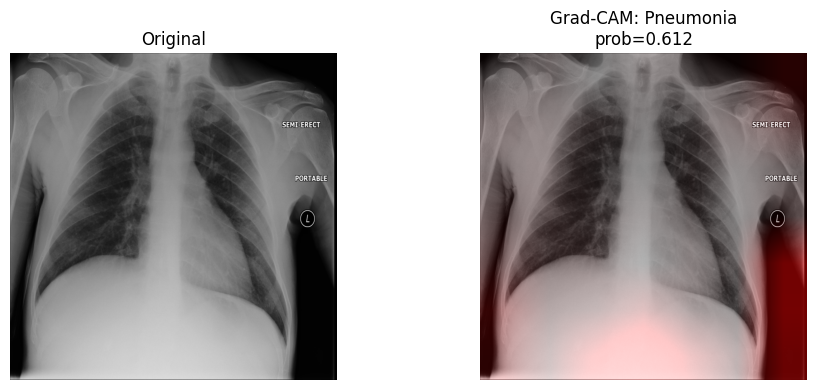

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Pneumonia_2.png


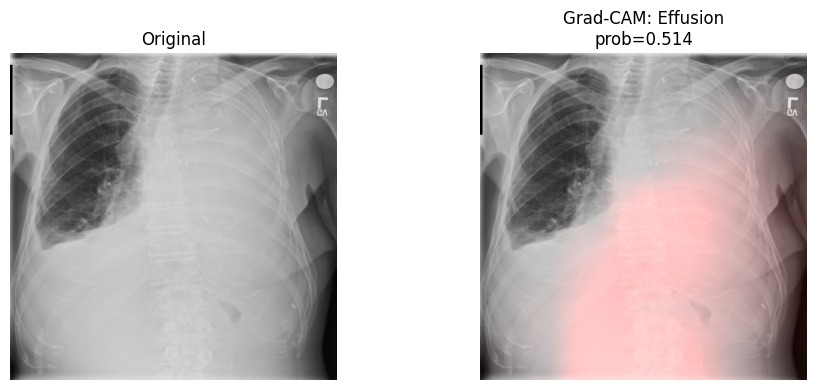

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Effusion_0.png


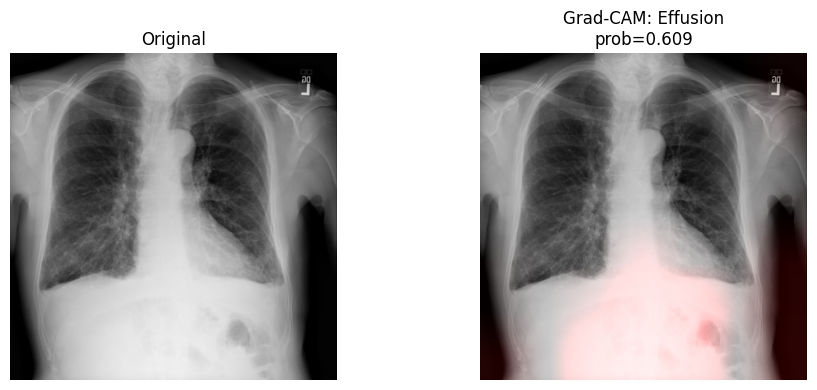

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Effusion_1.png


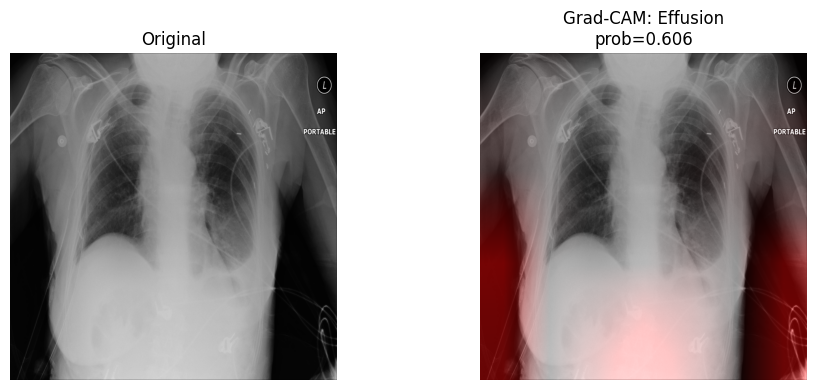

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Effusion_2.png


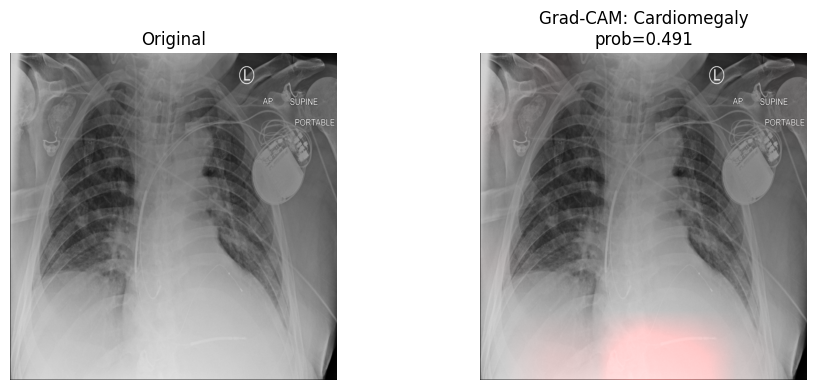

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Cardiomegaly_0.png


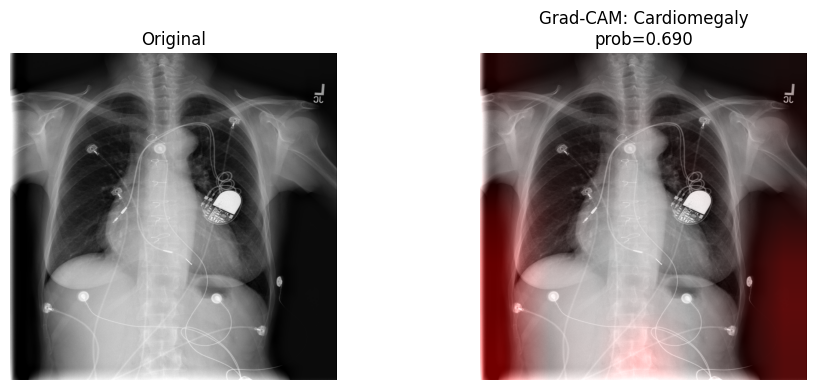

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Cardiomegaly_1.png


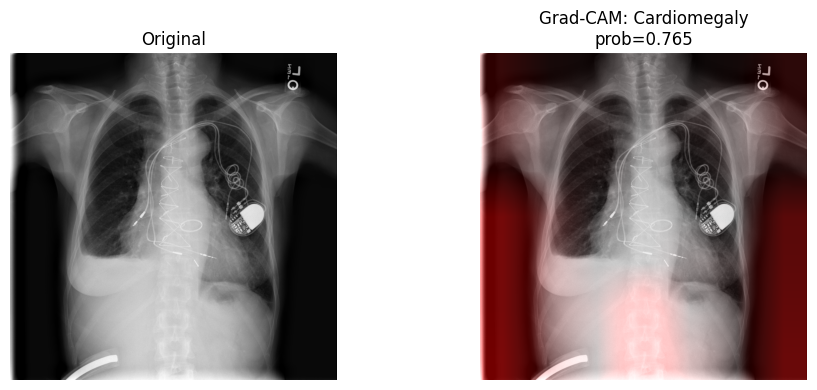

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_Cardiomegaly_2.png


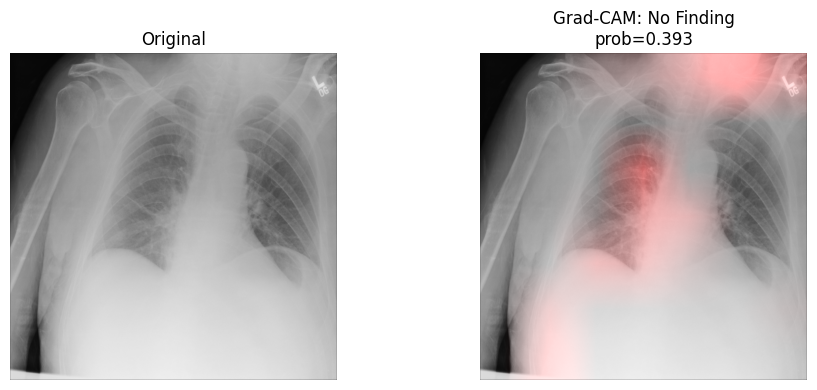

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_No_Finding_0.png


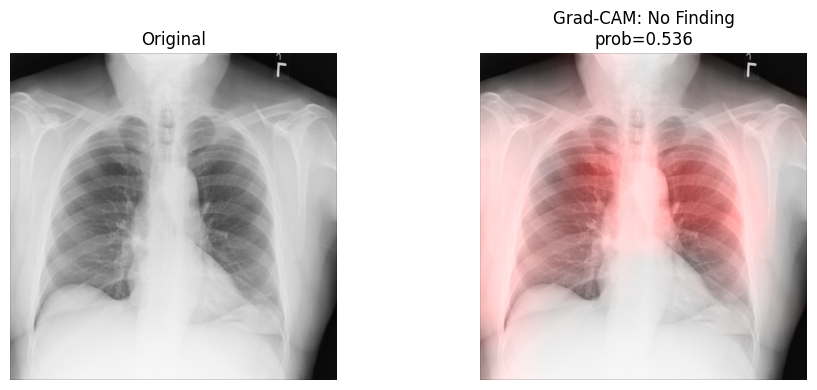

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_No_Finding_1.png


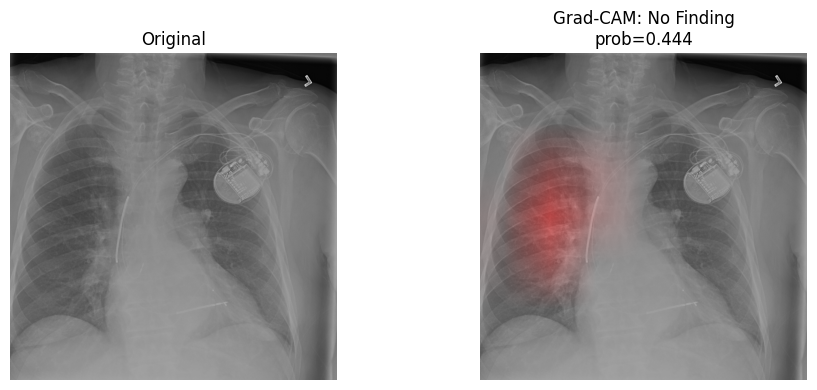

Saved: /content/drive/MyDrive/NIH/reports_resnet/gradcam_No_Finding_2.png

✅ Done. Outputs saved in: /content/drive/MyDrive/NIH/reports_resnet


In [13]:
# =========================
# TEST EVAL + PLOTS + GRAD-CAM (ResNet50)
# =========================

import os, json, numpy as np, pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

IMG_DIR = "/content/NIH_local_images/images"
TEST_CSV = "/content/nih-cxr-lt_single-label_test.csv"
CKPT_PATH = "/content/drive/MyDrive/NIH/models/resnet50_multilabel_best.pt"

TOP_N_CURVES = 8
GRADCAM_LABELS = ["Pneumonia", "Effusion", "Cardiomegaly", "No Finding"]
NUM_GRADCAM_IMAGES = 3

OUT_DIR = "/content/drive/MyDrive/NIH/reports_resnet"
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE = 128
NUM_WORKERS = 8

assert os.path.exists(IMG_DIR), f"IMG_DIR not found: {IMG_DIR}"
assert os.path.exists(TEST_CSV), f"TEST_CSV not found: {TEST_CSV}"
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
print("\u2705 Paths ok.")

# =========================
# LOAD TEST DATA
# =========================
test_df = pd.read_csv(TEST_CSV)

IMG_COL = "id"
IGNORE_COLS = {"id", "subject_id"}
LABEL_COLS = [c for c in test_df.columns if c not in IGNORE_COLS]

print("Test rows:", len(test_df))
print("Num labels:", len(LABEL_COLS))

from torch.utils.data import DataLoader

test_ds = CXRMultiLabelDataset(test_df, IMG_DIR, IMG_COL, LABEL_COLS, transform=val_tfms)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# =========================
# RECREATE MODEL FRESH + LOAD WEIGHTS
# =========================
import torchvision.models as models
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(LABEL_COLS))

ckpt = torch.load(CKPT_PATH, map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model = model.to(device)
model.eval()
print("\u2705 Loaded checkpoint into fresh ResNet50 model:", CKPT_PATH)

# =========================
# COLLECT PROBS + TARGETS
# =========================
@torch.no_grad()
def collect_probs_targets(model, loader):
    probs_all, targets_all = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            logits = model(x)
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        targets_all.append(y.numpy())
    return np.concatenate(probs_all, 0), np.concatenate(targets_all, 0)

test_probs, test_targets = collect_probs_targets(model, test_loader)

# =========================
# METRICS
# =========================
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

per_auc = {}
per_ap  = {}
aucs = []

for i, name in enumerate(LABEL_COLS):
    if len(np.unique(test_targets[:, i])) < 2:
        per_auc[name] = None
        per_ap[name] = None
        continue
    a  = roc_auc_score(test_targets[:, i], test_probs[:, i])
    ap = average_precision_score(test_targets[:, i], test_probs[:, i])
    per_auc[name] = float(a)
    per_ap[name]  = float(ap)
    aucs.append(a)

valid = len(aucs)
mean_auc = float(np.mean(aucs)) if aucs else float("nan")
print(f"\n\u2705 TEST mean AUC (over {valid} valid classes): {mean_auc:.4f}")

metrics_path = os.path.join(OUT_DIR, "test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump({"mean_auc": mean_auc, "per_auc": per_auc, "per_ap": per_ap}, f, indent=2)
print("Saved metrics:", metrics_path)

auc_items = [(k, v) for k, v in per_auc.items() if v is not None]
auc_items_sorted = sorted(auc_items, key=lambda x: x[1], reverse=True)

print("\nTop AUCs:")
for k, v in auc_items_sorted[:10]:
    print(f"  {k:30s} {v:.3f}")

print("\nBottom AUCs:")
for k, v in auc_items_sorted[-10:]:
    print(f"  {k:30s} {v:.3f}")

# =========================
# PLOT 1: Per-class AUC bar chart (top 15)
# =========================
top15 = auc_items_sorted[:15]
plt.figure(figsize=(10, 5))
plt.bar([k for k, _ in top15], [v for _, v in top15])
plt.xticks(rotation=60, ha="right")
plt.ylabel("AUC")
plt.title("Top 15 Classes by Test AUC (ResNet50)")
plt.tight_layout()
p1 = os.path.join(OUT_DIR, "auc_top15.png")
plt.savefig(p1, dpi=200)
plt.show()
print("Saved:", p1)

# =========================
# PLOT 2: ROC curves
# =========================
plt.figure(figsize=(7, 7))
for name, _auc in auc_items_sorted[:TOP_N_CURVES]:
    i = LABEL_COLS.index(name)
    fpr, tpr, _ = roc_curve(test_targets[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves (Top {TOP_N_CURVES} Classes)")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
p2 = os.path.join(OUT_DIR, "roc_topN.png")
plt.savefig(p2, dpi=200)
plt.show()
print("Saved:", p2)

# =========================
# PLOT 3: Precision-Recall curves
# =========================
ap_items = [(k, v) for k, v in per_ap.items() if v is not None]
ap_items_sorted = sorted(ap_items, key=lambda x: x[1], reverse=True)

plt.figure(figsize=(7, 7))
for name, _ap in ap_items_sorted[:TOP_N_CURVES]:
    i = LABEL_COLS.index(name)
    precision, recall, _ = precision_recall_curve(test_targets[:, i], test_probs[:, i])
    plt.plot(recall, precision, label=f"{name} (AP={_ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision\u2013Recall Curves (Top {TOP_N_CURVES} Classes)")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
p3 = os.path.join(OUT_DIR, "pr_topN.png")
plt.savefig(p3, dpi=200)
plt.show()
print("Saved:", p3)

# =========================
# GRAD-CAM for ResNet50
# Hooks into model.layer4 (last residual block)
# =========================
from PIL import Image

class GradCAMResNet:
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None

        def fwd_hook(module, inp, out):
            self.activations = out
            out.register_hook(self._save_grad)

        # Hook the last residual block (layer4)
        self.hook = self.model.layer4.register_forward_hook(fwd_hook)

    def _save_grad(self, grad):
        self.gradients = grad

    def remove(self):
        self.hook.remove()

    def __call__(self, x, class_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        target = logits[:, class_idx].sum()
        target.backward(retain_graph=True)

        grads = self.gradients
        acts  = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)
        cam = torch.clamp(cam, min=0)

        cam_min = cam.amin(dim=(1, 2), keepdim=True)
        cam_max = cam.amax(dim=(1, 2), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-6)

        return cam.detach().cpu().numpy(), logits.detach().cpu().numpy()

def overlay_cam_on_image(pil_img, cam_2d, alpha=0.45):
    heat = Image.fromarray((cam_2d * 255).astype(np.uint8)).resize(
        pil_img.size, resample=Image.BILINEAR
    )
    heat = np.array(heat) / 255.0

    img = np.array(pil_img).astype(np.float32) / 255.0
    overlay = img.copy()
    overlay[..., 0] = np.clip(overlay[..., 0] + alpha * heat, 0, 1)
    return (overlay * 255).astype(np.uint8)

# =========================
# GENERATE GRAD-CAM EXAMPLES
# =========================
model.eval()
cam_engine = GradCAMResNet(model)

sample_ids = test_df[IMG_COL].tolist()

for label in GRADCAM_LABELS:
    if label not in LABEL_COLS:
        print(f"\u26a0 Label '{label}' not in LABEL_COLS, skipping.")
        continue

    class_idx = LABEL_COLS.index(label)
    saved = 0

    positives = test_df[test_df[label] == 1][IMG_COL].tolist()
    candidates = positives if len(positives) > 0 else sample_ids

    for img_name in candidates:
        img_path = os.path.join(IMG_DIR, img_name)
        if not os.path.exists(img_path):
            continue

        pil_img = Image.open(img_path).convert("RGB")

        x = val_tfms(pil_img).unsqueeze(0).to(device, dtype=torch.float32)

        cam_map, logits = cam_engine(x, class_idx)
        prob = 1 / (1 + np.exp(-logits[0, class_idx]))

        over = overlay_cam_on_image(pil_img, cam_map[0], alpha=0.45)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(pil_img); plt.axis("off")
        plt.title("Original")

        plt.subplot(1, 2, 2)
        plt.imshow(over); plt.axis("off")
        plt.title(f"Grad-CAM: {label}\nprob={prob:.3f}")

        plt.tight_layout()
        out_path = os.path.join(OUT_DIR, f"gradcam_{label.replace(' ','_')}_{saved}.png")
        plt.savefig(out_path, dpi=200)
        plt.show()

        print("Saved:", out_path)
        saved += 1
        if saved >= NUM_GRADCAM_IMAGES:
            break

cam_engine.remove()
print("\n\u2705 Done. Outputs saved in:", OUT_DIR)